# Electricity Load Forecasting — Model Training

This notebook trains **four boosting models** to predict electricity consumption:

| # | Model | Library |
|---|-------|---------|
| 1 | XGBoost | `xgboost` |
| 2 | AdaBoost | `sklearn.ensemble` |
| 3 | CatBoost | `catboost` |
| 4 | LightGBM | `lightgbm` |

**Target:** Predict total electricity usage (sum of all meters) at each 15-minute interval.

**Features:** Time-based features (hour, day_of_week, month, etc.) and lagged/rolling consumption features.

## 1. Install Dependencies (if needed)

In [1]:
# Uncomment and run if packages are not installed
# !pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 3. Load Data

In [3]:
DATA_FILE = 'LD2011_2014.csv'

print(f'Loading {DATA_FILE}...')
df = pd.read_csv(
    DATA_FILE,
    sep=';',
    decimal=',',
    index_col=0,
    parse_dates=True
)
df.index.name = 'datetime'

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
df.head()

Loading LD2011_2014.csv...
Shape: (140256, 370)
Date range: 2011-01-01 00:15:00 to 2015-01-01 00:00:00


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Create Target Variable

The target is **total_consumption** — the sum of all meter readings at each timestamp.

In [4]:
# Sum all meter columns to create the target
meter_cols = [c for c in df.columns if c.startswith('MT_')]
df['total_consumption'] = df[meter_cols].sum(axis=1)

print(f'Number of meters: {len(meter_cols)}')
print(f'Target statistics:')
df['total_consumption'].describe()

Number of meters: 370
Target statistics:


count    140256.000000
mean     195556.942526
std       84259.360145
min         342.595509
25%      131128.411567
50%      167856.513526
75%      248834.303388
max      452652.595567
Name: total_consumption, dtype: float64

## 5. Feature Engineering

In [5]:
# 5.1 Time-based features
df['hour'] = df.index.hour
df['minute'] = df.index.minute
df['day_of_week'] = df.index.dayofweek      # 0=Mon, 6=Sun
df['day_of_month'] = df.index.day
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month
df['year'] = df.index.year
df['quarter'] = df.index.quarter
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# 5.2 Cyclical time encoding (helps tree models understand circular time)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Time features created.')
print(f'Columns: {[c for c in df.columns if c not in meter_cols]}')

Time features created.
Columns: ['total_consumption', 'hour', 'minute', 'day_of_week', 'day_of_month', 'day_of_year', 'month', 'year', 'quarter', 'week_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


In [6]:
# 5.3 Lag features (past consumption values)
LAG_STEPS = [1, 4, 96, 96*7]  # 15min, 1hr, 1day, 1week
LAG_NAMES = ['lag_15min', 'lag_1hr', 'lag_1day', 'lag_1week']

for lag, name in zip(LAG_STEPS, LAG_NAMES):
    df[name] = df['total_consumption'].shift(lag)

# 5.4 Rolling window features
WINDOWS = [4, 96, 96*7]  # 1hr, 1day, 1week
WIN_NAMES = ['1hr', '1day', '1week']

for win, name in zip(WINDOWS, WIN_NAMES):
    df[f'rolling_mean_{name}'] = df['total_consumption'].shift(1).rolling(window=win).mean()
    df[f'rolling_std_{name}'] = df['total_consumption'].shift(1).rolling(window=win).std()

# Drop rows with NaN from lagging/rolling
initial_rows = len(df)
df.dropna(inplace=True)
print(f'Rows dropped due to lag/rolling NaNs: {initial_rows - len(df)}')
print(f'Remaining rows: {len(df)}')

Rows dropped due to lag/rolling NaNs: 672
Remaining rows: 139584


## 6. Prepare Feature Matrix & Target

In [7]:
# Select feature columns (exclude meter columns and target)
FEATURE_COLS = [
    'hour', 'minute', 'day_of_week', 'day_of_month', 'day_of_year',
    'month', 'year', 'quarter', 'week_of_year', 'is_weekend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'lag_15min', 'lag_1hr', 'lag_1day', 'lag_1week',
    'rolling_mean_1hr', 'rolling_std_1hr',
    'rolling_mean_1day', 'rolling_std_1day',
    'rolling_mean_1week', 'rolling_std_1week'
]

TARGET_COL = 'total_consumption'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures used ({len(FEATURE_COLS)}):')
for i, c in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {c}')

Feature matrix shape: (139584, 26)
Target shape: (139584,)

Features used (26):
   1. hour
   2. minute
   3. day_of_week
   4. day_of_month
   5. day_of_year
   6. month
   7. year
   8. quarter
   9. week_of_year
  10. is_weekend
  11. hour_sin
  12. hour_cos
  13. month_sin
  14. month_cos
  15. dow_sin
  16. dow_cos
  17. lag_15min
  18. lag_1hr
  19. lag_1day
  20. lag_1week
  21. rolling_mean_1hr
  22. rolling_std_1hr
  23. rolling_mean_1day
  24. rolling_std_1day
  25. rolling_mean_1week
  26. rolling_std_1week


## 7. Train/Test Split

For time series, we use a **temporal split** — train on earlier data, test on later data. No shuffling.

In [8]:
SPLIT_RATIO = 0.8
split_idx = int(len(X) * SPLIT_RATIO)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Training set: {X_train.shape[0]} rows ({X_train.index.min()} to {X_train.index.max()})')
print(f'Test set:     {X_test.shape[0]} rows ({X_test.index.min()} to {X_test.index.max()})')

Training set: 111667 rows (2011-01-08 00:15:00 to 2014-03-16 04:45:00)
Test set:     27917 rows (2014-03-16 05:00:00 to 2015-01-01 00:00:00)


## 8. Define Evaluation Metrics

In [9]:
def evaluate_model(name, y_true, y_pred):
    """Calculate and print regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    metrics = {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape
    }
    
    print(f'\n=== {name} ===')
    print(f'  MAE:      {mae:,.2f}')
    print(f'  RMSE:     {rmse:,.2f}')
    print(f'  R²:       {r2:.6f}')
    print(f'  MAPE:     {mape:.2f}%')
    
    return metrics

# Store all results
all_results = []
all_predictions = {}
all_models = {}

print('Evaluation function ready.')

Evaluation function ready.


## 9. Train Models

### 9.1 XGBoost

In [10]:
print('Training XGBoost...')
start = time.time()

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_time = time.time() - start

result = evaluate_model('XGBoost', y_test, xgb_pred)
result['Time (s)'] = round(xgb_time, 2)
all_results.append(result)
all_predictions['XGBoost'] = xgb_pred
all_models['XGBoost'] = xgb_model

print(f'  Training time: {xgb_time:.2f}s')

Training XGBoost...

=== XGBoost ===
  MAE:      4,078.09
  RMSE:     6,332.17
  R²:       0.994336
  MAPE:     3.32%
  Training time: 3.11s


### 9.2 AdaBoost

In [11]:
print('Training AdaBoost...')
start = time.time()

ada_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=6),
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)
ada_time = time.time() - start

result = evaluate_model('AdaBoost', y_test, ada_pred)
result['Time (s)'] = round(ada_time, 2)
all_results.append(result)
all_predictions['AdaBoost'] = ada_pred
all_models['AdaBoost'] = ada_model

print(f'  Training time: {ada_time:.2f}s')

Training AdaBoost...

=== AdaBoost ===
  MAE:      5,150.47
  RMSE:     7,416.28
  R²:       0.992231
  MAPE:     3.76%
  Training time: 159.93s


### 9.3 CatBoost

In [12]:
print('Training CatBoost...')
start = time.time()

cat_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=False
)

cat_pred = cat_model.predict(X_test)
cat_time = time.time() - start

result = evaluate_model('CatBoost', y_test, cat_pred)
result['Time (s)'] = round(cat_time, 2)
all_results.append(result)
all_predictions['CatBoost'] = cat_pred
all_models['CatBoost'] = cat_model

print(f'  Training time: {cat_time:.2f}s')

Training CatBoost...

=== CatBoost ===
  MAE:      4,172.23
  RMSE:     6,412.02
  R²:       0.994192
  MAPE:     3.51%
  Training time: 5.63s


### 9.4 LightGBM

In [13]:
print('Training LightGBM...')
start = time.time()

lgbm_model = LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_time = time.time() - start

result = evaluate_model('LightGBM', y_test, lgbm_pred)
result['Time (s)'] = round(lgbm_time, 2)
all_results.append(result)
all_predictions['LightGBM'] = lgbm_pred
all_models['LightGBM'] = lgbm_model

print(f'  Training time: {lgbm_time:.2f}s')

Training LightGBM...

=== LightGBM ===
  MAE:      4,092.79
  RMSE:     6,301.45
  R²:       0.994391
  MAPE:     3.62%
  Training time: 1.45s


## 10. Model Comparison

In [14]:
# 10.1 Results table
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('RMSE')

print('=== Model Comparison (sorted by RMSE) ===')
results_df

=== Model Comparison (sorted by RMSE) ===


,MAE,RMSE,R²,MAPE (%),Time (s)
Model,,,,,
LightGBM,4092.785192,6301.446379,0.994391,3.618880,1.45
XGBoost,4078.090302,6332.172342,0.994336,3.320622,3.11
CatBoost,4172.230626,6412.021890,0.994192,3.505728,5.63
AdaBoost,5150.472202,7416.279802,0.992231,3.762621,159.93


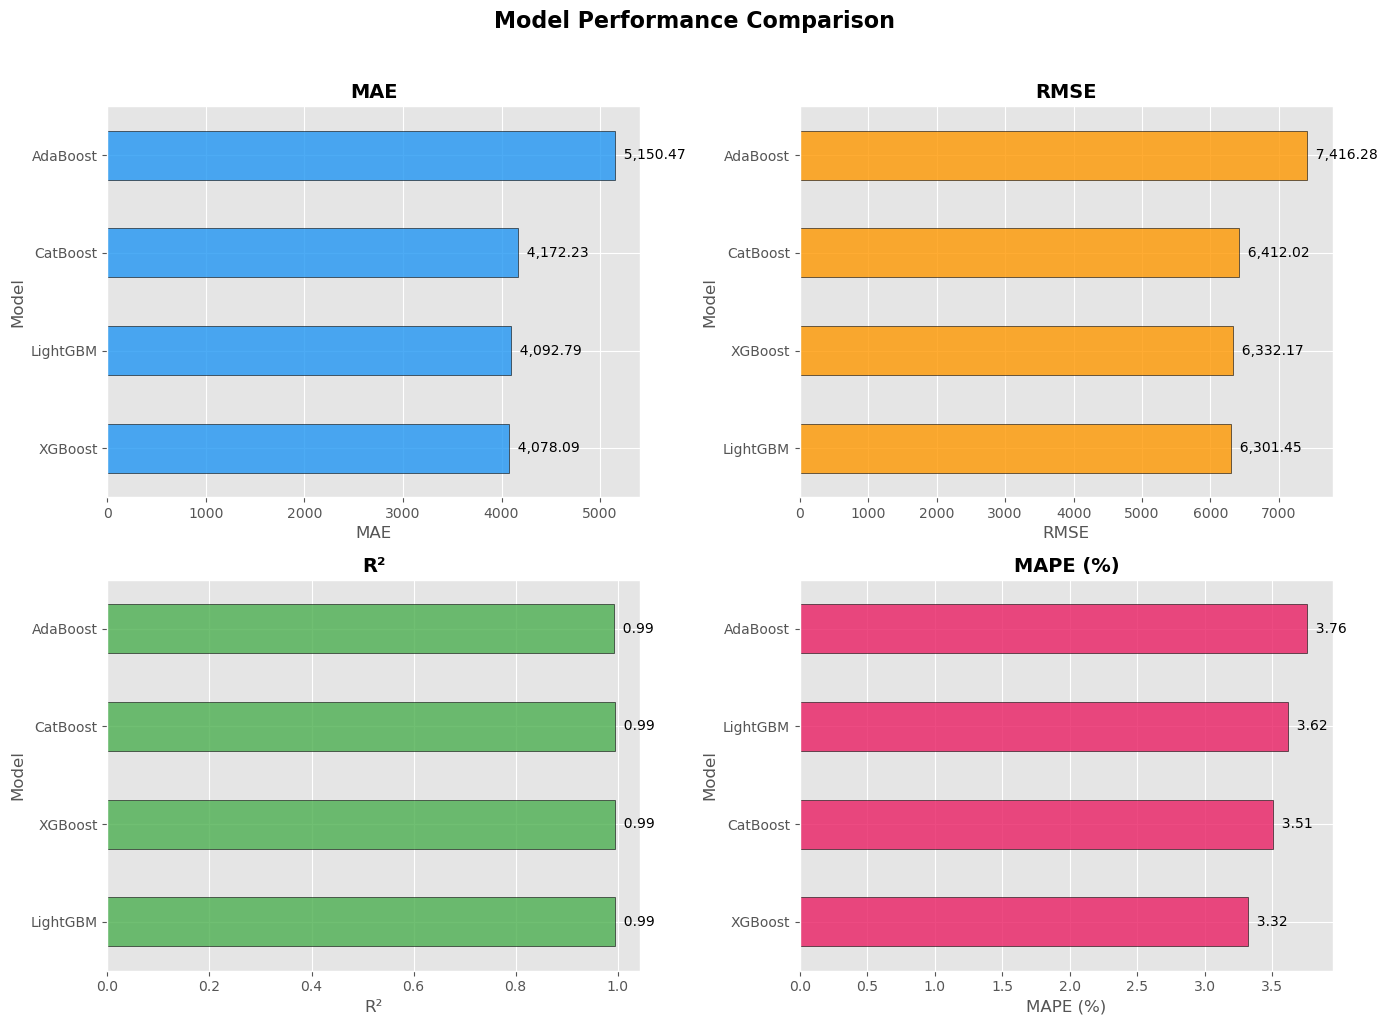

In [15]:
# 10.2 Bar chart comparison of metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

for ax, metric, color in zip(axes.flatten(), metrics_to_plot, colors):
    data = results_df[metric].sort_values(ascending=(metric != 'R²'))
    data.plot(kind='barh', ax=ax, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xlabel(metric)
    # Add value labels
    for i, (val, name) in enumerate(zip(data.values, data.index)):
        ax.text(val, i, f'  {val:,.2f}', va='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

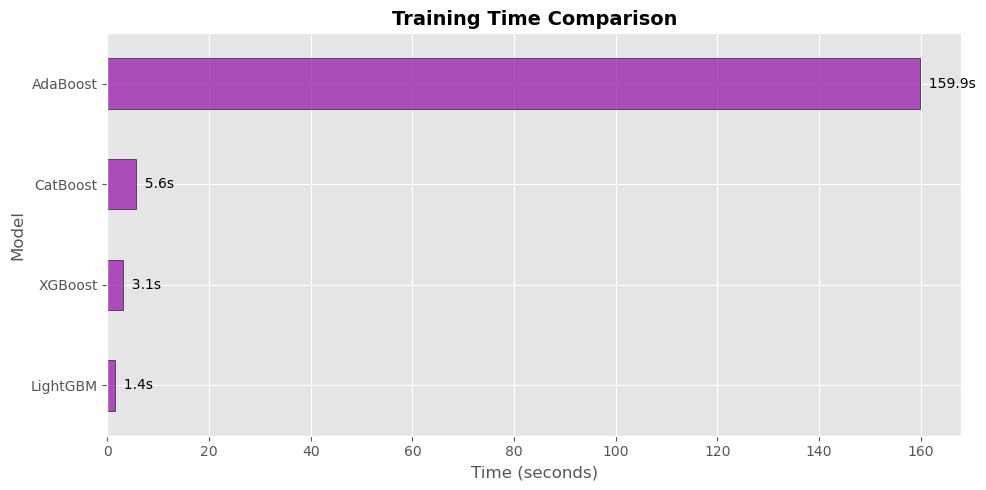

In [16]:
# 10.3 Training time comparison
fig, ax = plt.subplots(figsize=(10, 5))
time_data = results_df['Time (s)'].sort_values()
time_data.plot(kind='barh', ax=ax, color='#9C27B0', edgecolor='black', alpha=0.8)
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (seconds)')
for i, (val, name) in enumerate(zip(time_data.values, time_data.index)):
    ax.text(val, i, f'  {val:.1f}s', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 11. Predictions vs Actual — Visual Comparison

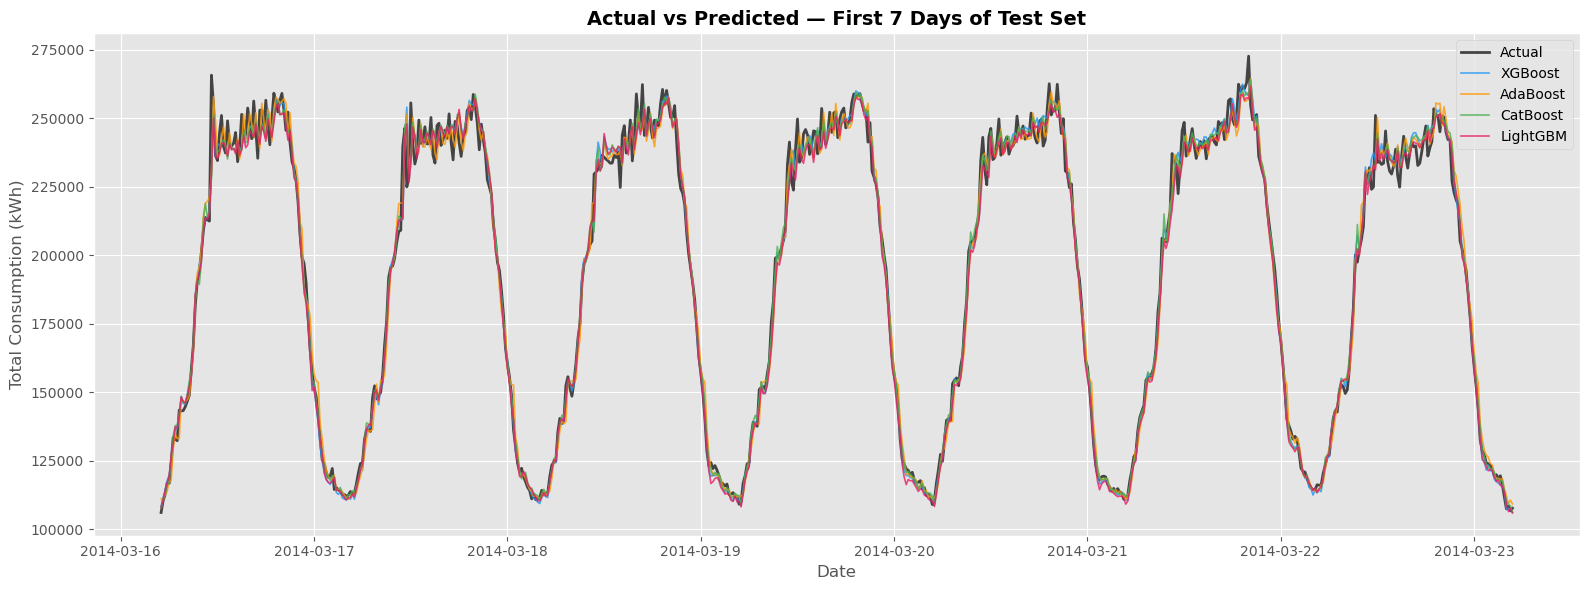

In [17]:
# 11.1 Time-series overlay — first 7 days of test set
n_plot = 96 * 7  # 7 days at 15-min intervals

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_test.index[:n_plot], y_test.values[:n_plot],
        label='Actual', color='black', linewidth=2, alpha=0.7)

model_colors = {'XGBoost': '#2196F3', 'AdaBoost': '#FF9800',
                'CatBoost': '#4CAF50', 'LightGBM': '#E91E63'}

for name, pred in all_predictions.items():
    ax.plot(y_test.index[:n_plot], pred[:n_plot],
            label=name, linewidth=1.2, alpha=0.8, color=model_colors[name])

ax.set_title('Actual vs Predicted — First 7 Days of Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Consumption (kWh)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

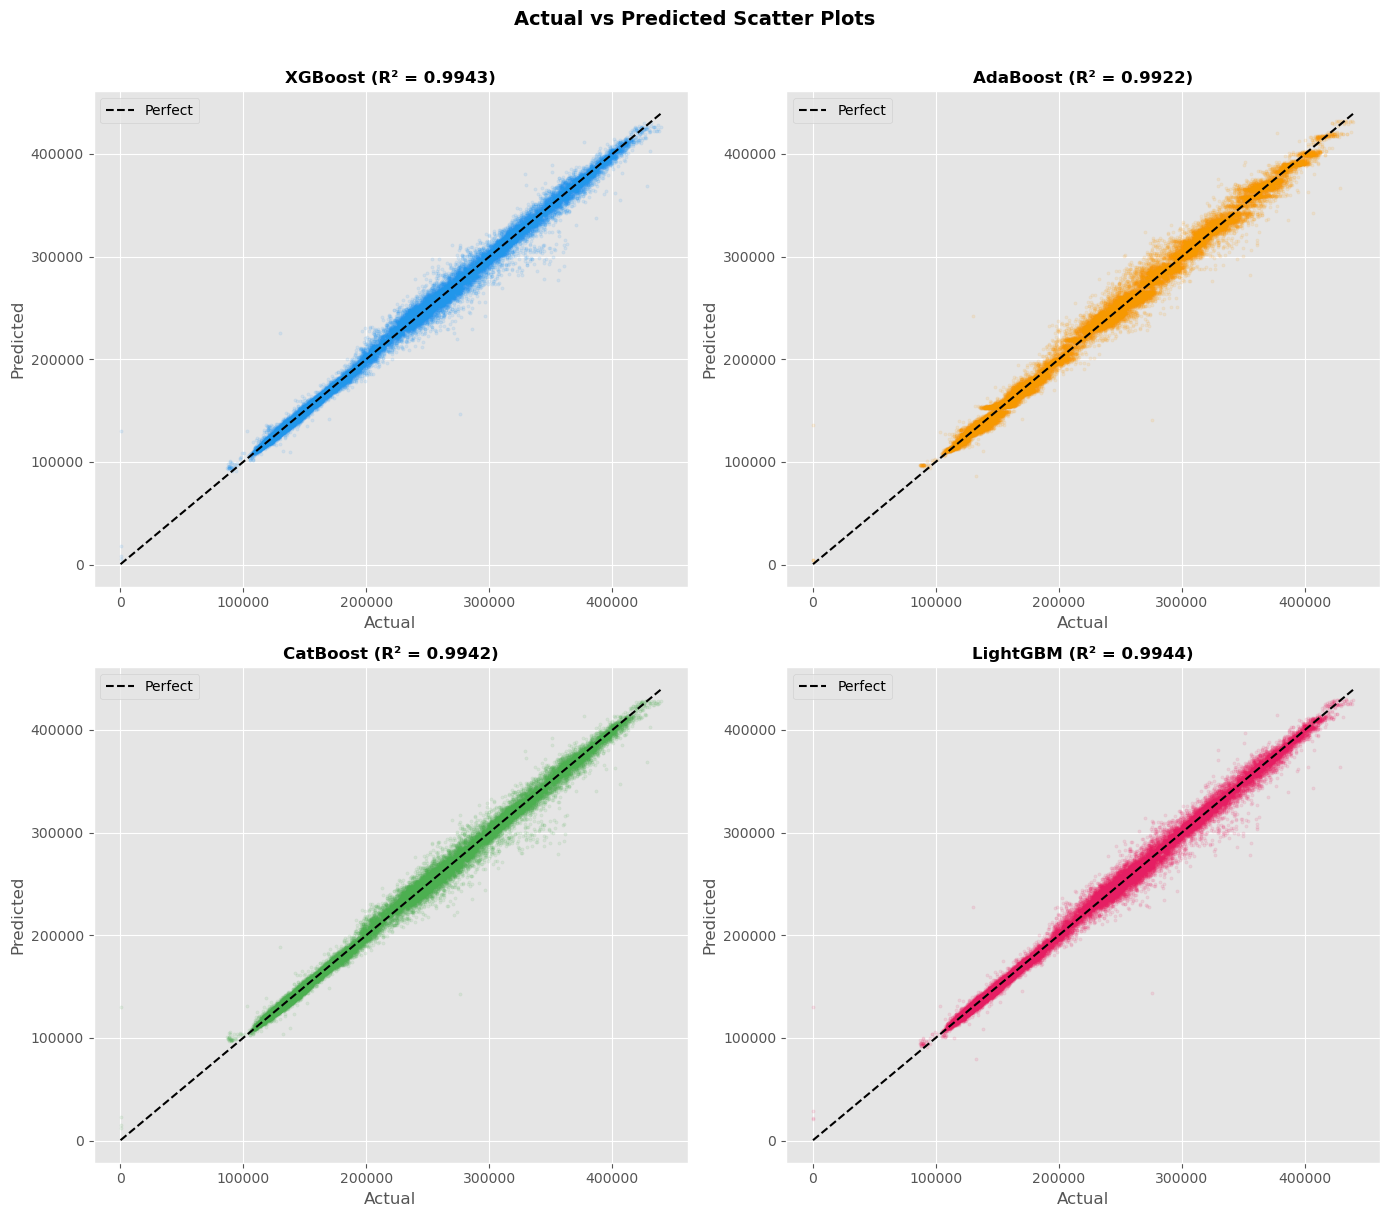

In [18]:
# 11.2 Scatter plots — Actual vs Predicted for each model
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, pred) in zip(axes.flatten(), all_predictions.items()):
    ax.scatter(y_test.values, pred, alpha=0.1, s=5, color=model_colors[name])
    # Perfect prediction line
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect')
    ax.set_title(f'{name} (R² = {r2_score(y_test, pred):.4f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()

plt.suptitle('Actual vs Predicted Scatter Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 12. Feature Importance

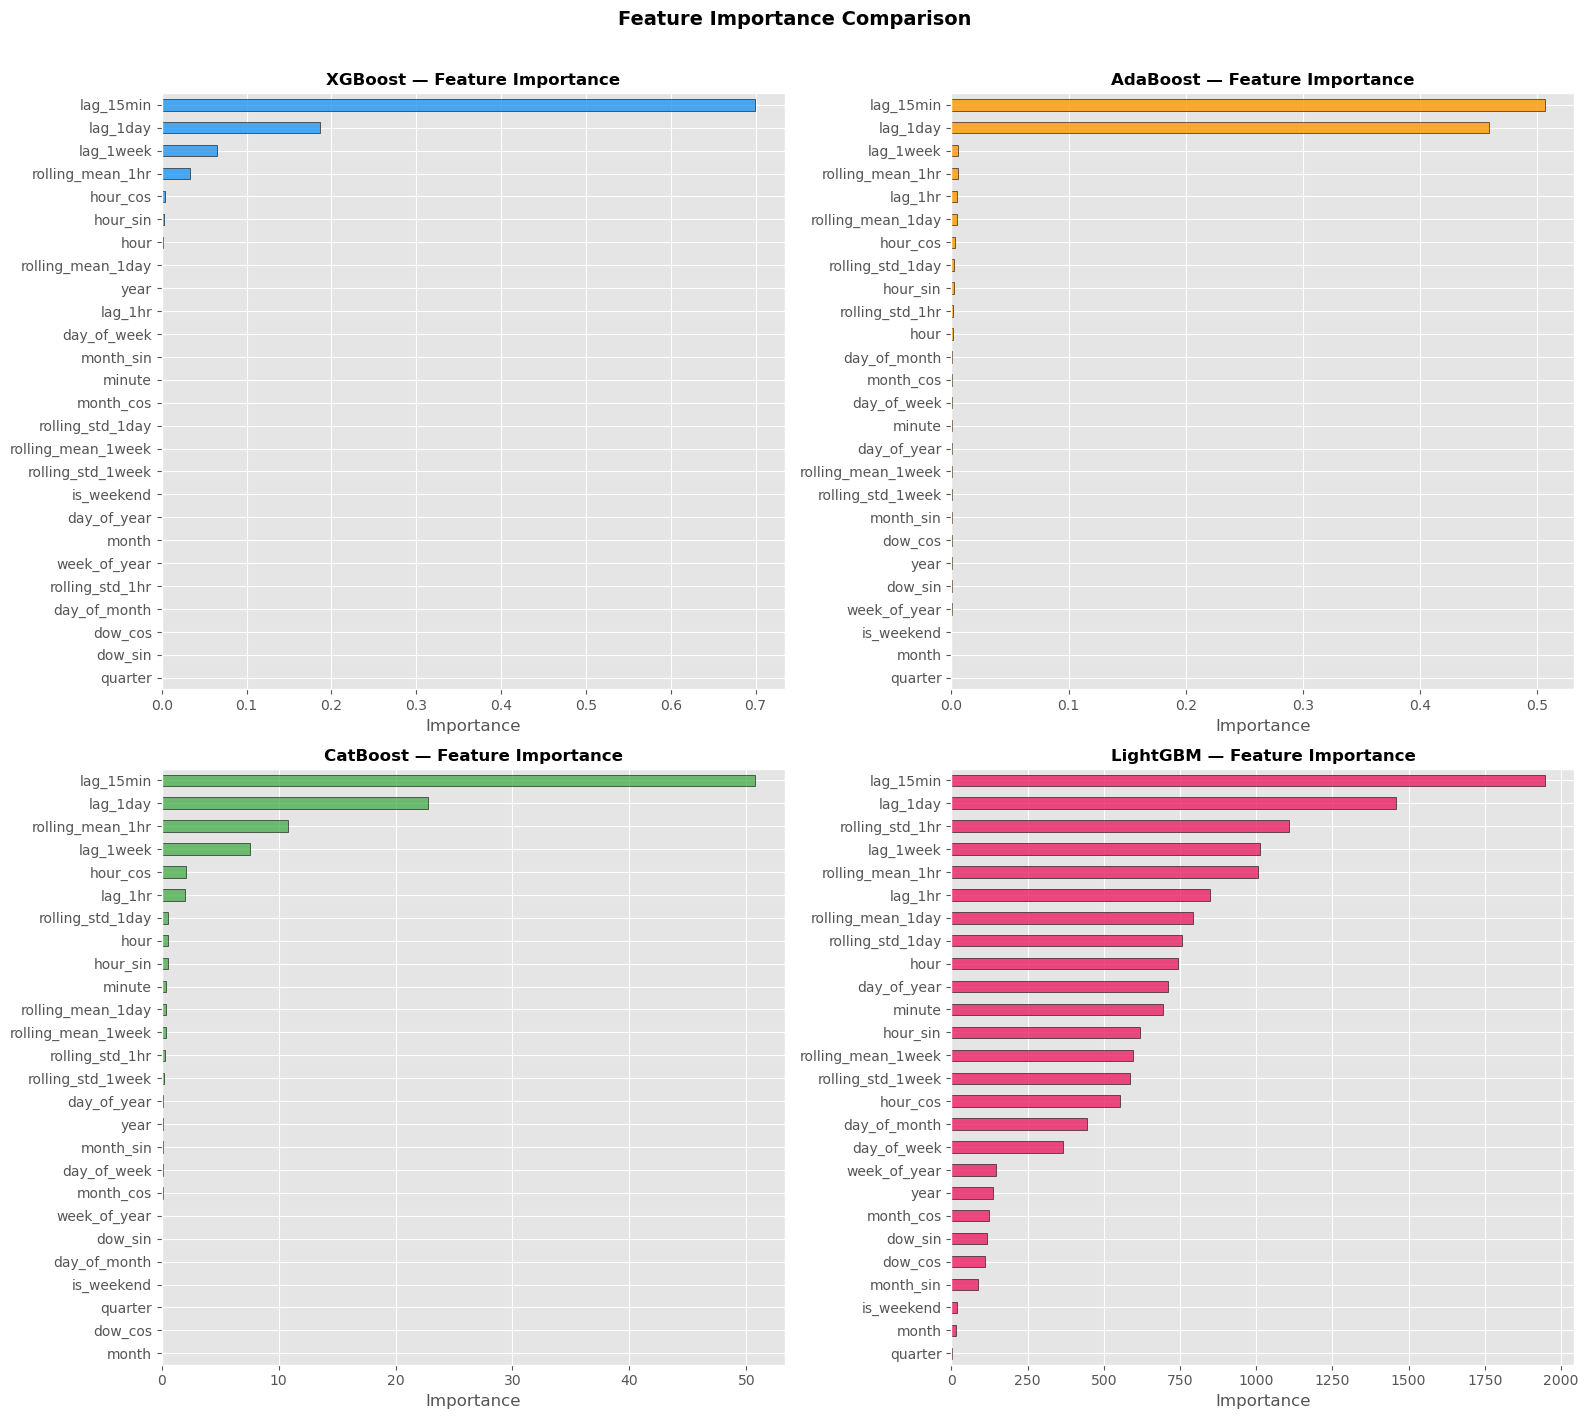

In [19]:
# 12.1 Feature importance for each model
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, (name, model) in zip(axes.flatten(), all_models.items()):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
    else:
        continue
    
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=ax, color=model_colors[name], edgecolor='black', alpha=0.8)
    ax.set_title(f'{name} — Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 13. Residual Analysis

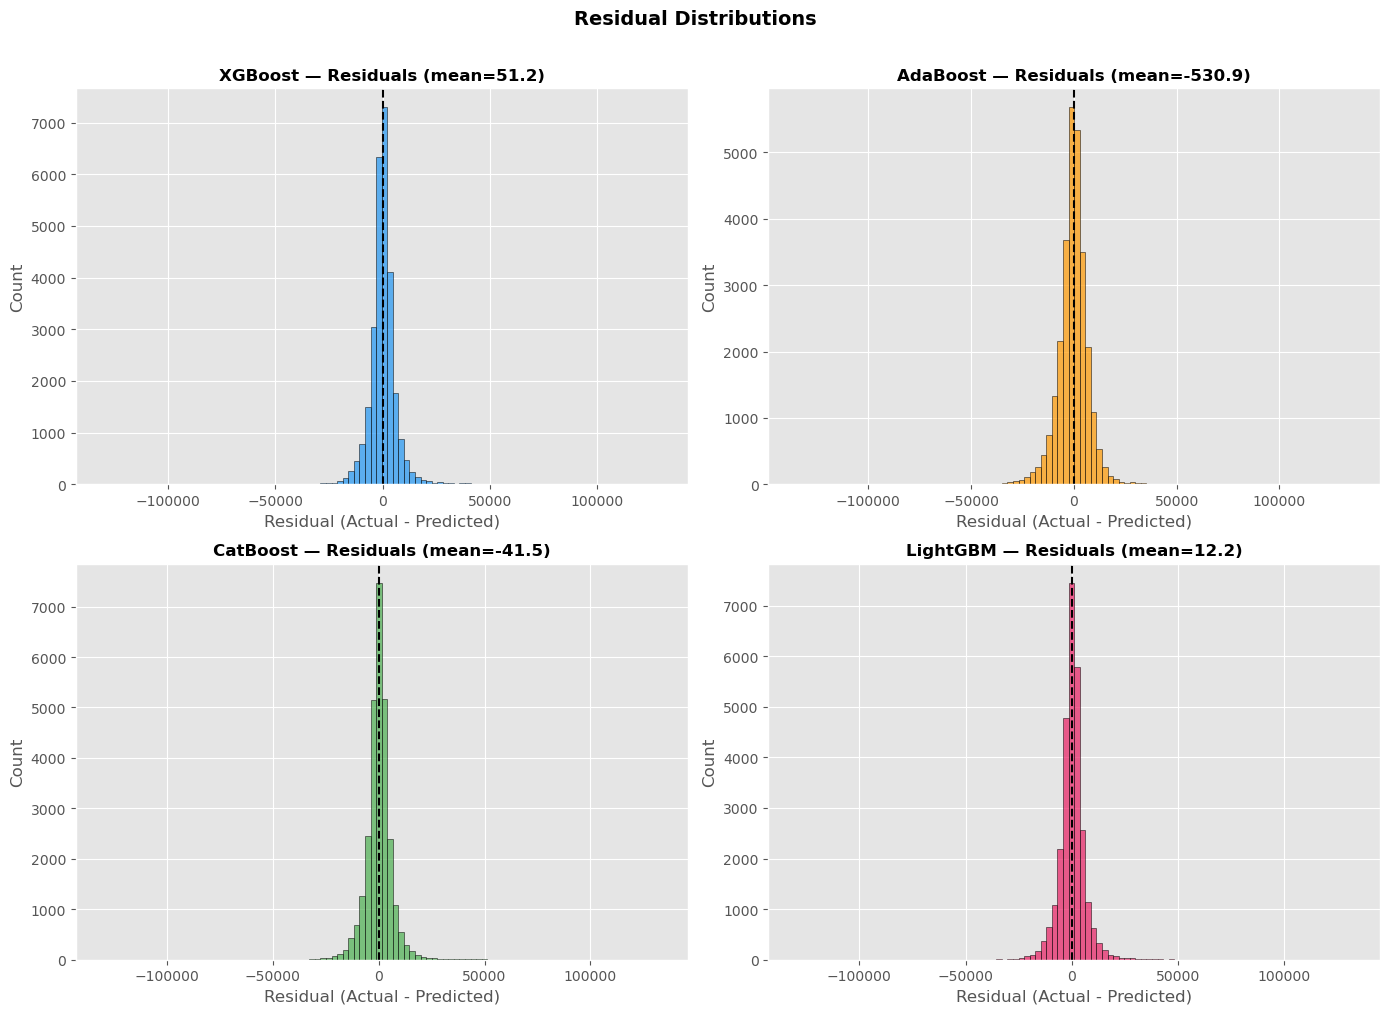

In [20]:
# 13.1 Residual distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, pred) in zip(axes.flatten(), all_predictions.items()):
    residuals = y_test.values - pred
    ax.hist(residuals, bins=100, color=model_colors[name], edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name} — Residuals (mean={np.mean(residuals):,.1f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Count')

plt.suptitle('Residual Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

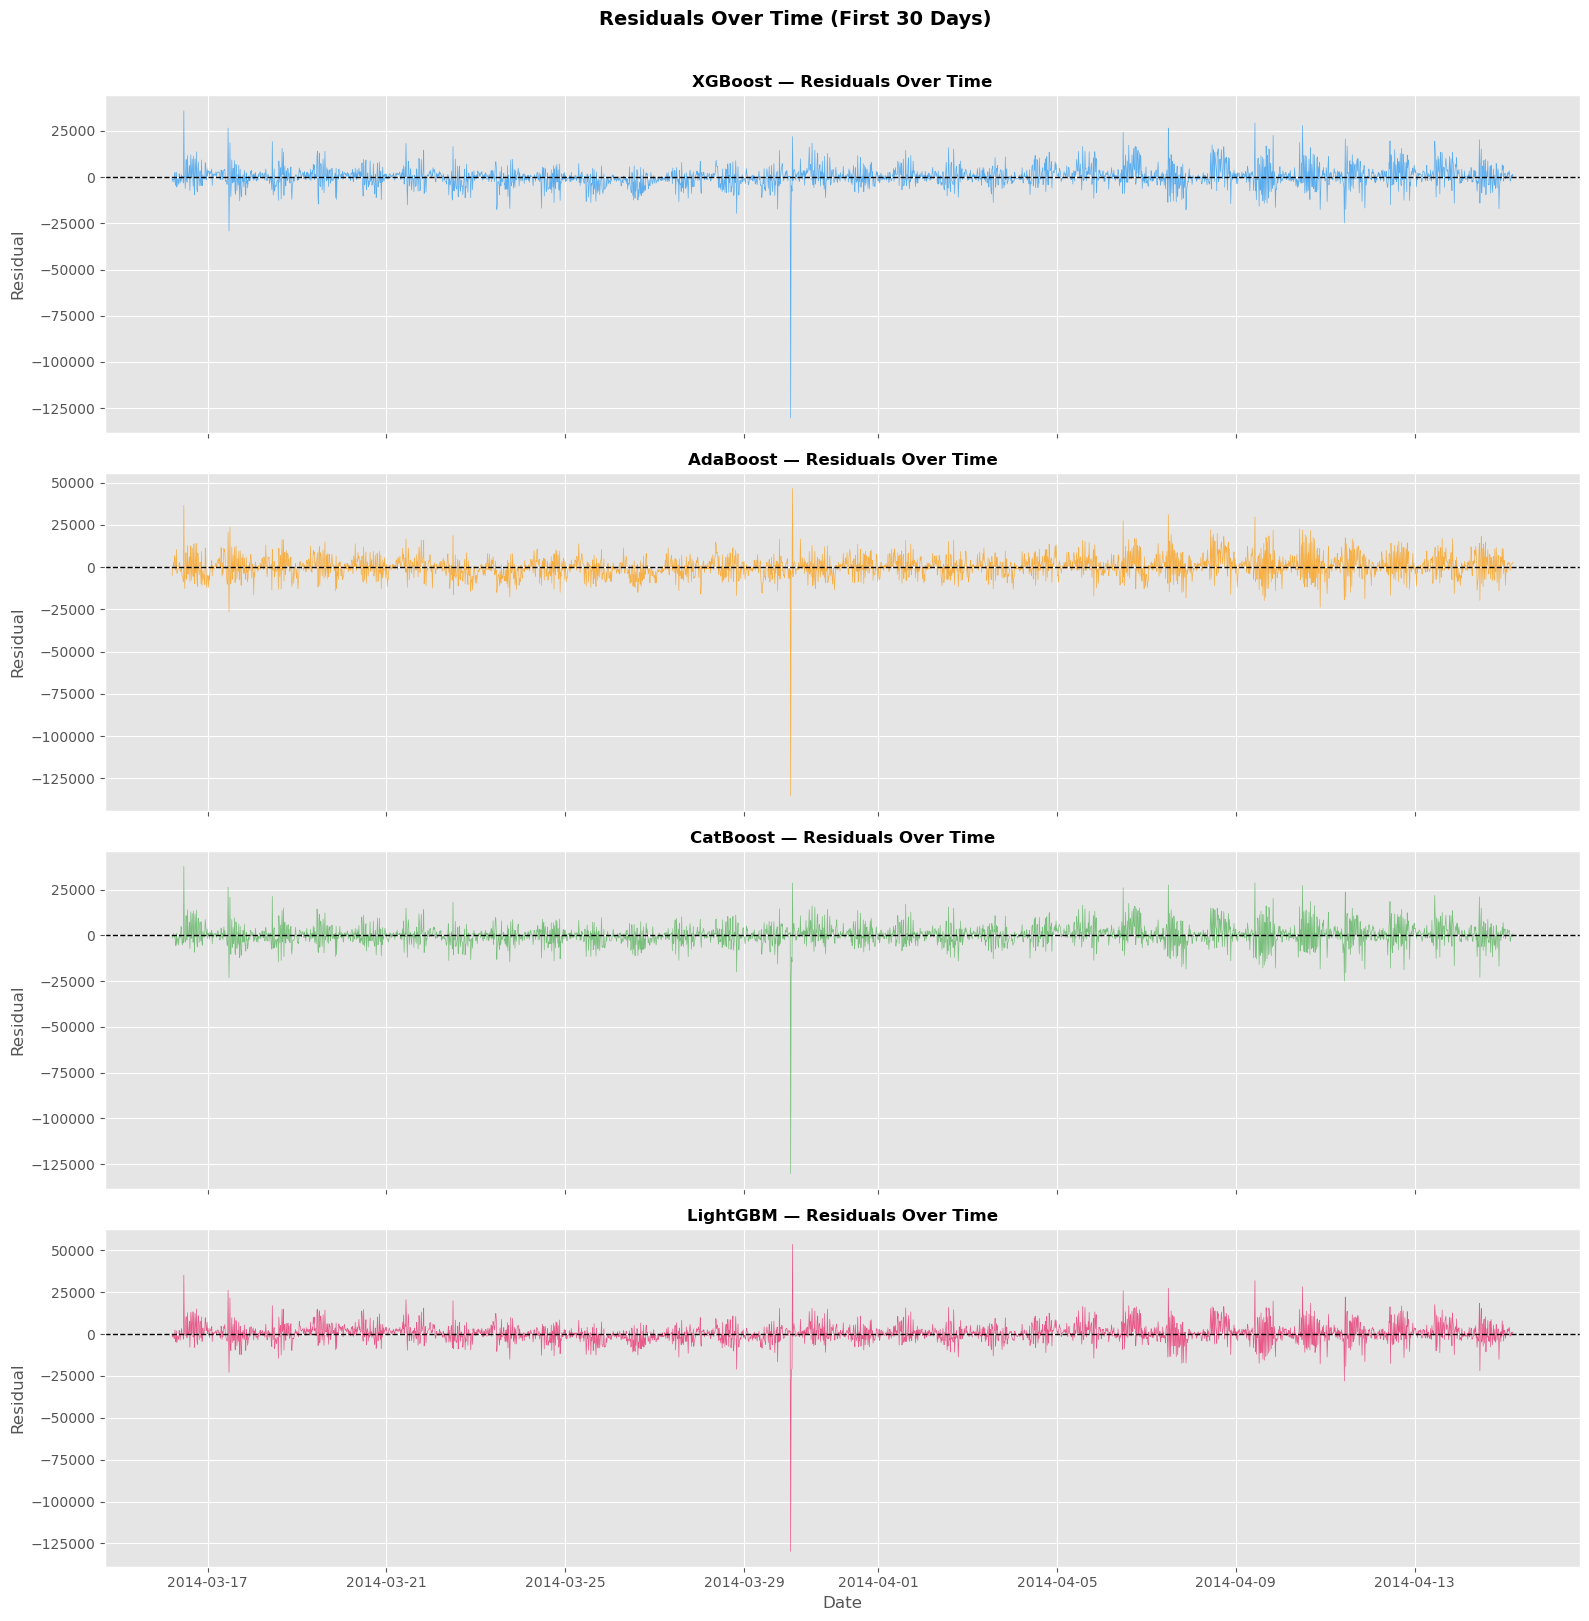

In [21]:
# 13.2 Residuals over time (first 30 days of test set)
n_plot = 96 * 30  # 30 days

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

for ax, (name, pred) in zip(axes, all_predictions.items()):
    residuals = y_test.values[:n_plot] - pred[:n_plot]
    ax.plot(y_test.index[:n_plot], residuals,
            linewidth=0.5, color=model_colors[name], alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{name} — Residuals Over Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Residual')

axes[-1].set_xlabel('Date')
plt.suptitle('Residuals Over Time (First 30 Days)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 14. Save Models

In [22]:
import os

MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

for name, model in all_models.items():
    filepath = os.path.join(MODEL_DIR, f'{name.lower()}_model.pkl')
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved {name} -> {filepath}')

# Save results
results_df.to_csv(os.path.join(MODEL_DIR, 'model_comparison_results.csv'))
print(f'\nResults saved to {MODEL_DIR}/model_comparison_results.csv')

Saved XGBoost -> saved_models\xgboost_model.pkl
Saved AdaBoost -> saved_models\adaboost_model.pkl
Saved CatBoost -> saved_models\catboost_model.pkl
Saved LightGBM -> saved_models\lightgbm_model.pkl

Results saved to saved_models/model_comparison_results.csv


## 15. Summary

In [24]:
print('=' * 70)
print('MODEL TRAINING SUMMARY')
print('=' * 70)
print(f'\nDataset:          {DATA_FILE}')
print(f'Date range:       {df.index.min()} to {df.index.max()}')
print(f'Total samples:    {len(df):,}')
print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Features used:    {len(FEATURE_COLS)}')
print(f'Target:           total_consumption (sum of all meters)')
print(f'\n--- Results (sorted by RMSE) ---')
print(results_df.to_string())

best_model = results_df.index[0]
print(f'\n Best model by RMSE: {best_model}')
print(f'   RMSE:  {results_df.loc[best_model, "RMSE"]:,.2f}')
print(f'   R²:    {results_df.loc[best_model, "R²"]:.6f}')
print(f'   MAPE:  {results_df.loc[best_model, "MAPE (%)"]:.2f}%')
print(f'\nAll models saved to: {MODEL_DIR}/')

MODEL TRAINING SUMMARY

Dataset:          LD2011_2014.csv
Date range:       2011-01-08 00:15:00 to 2015-01-01 00:00:00
Total samples:    139,584
Training samples: 111,667
Test samples:     27,917
Features used:    26
Target:           total_consumption (sum of all meters)

--- Results (sorted by RMSE) ---
                  MAE         RMSE        R²  MAPE (%)  Time (s)
Model                                                           
LightGBM  4092.785192  6301.446379  0.994391  3.618880      1.45
XGBoost   4078.090302  6332.172342  0.994336  3.320622      3.11
CatBoost  4172.230626  6412.021890  0.994192  3.505728      5.63
AdaBoost  5150.472202  7416.279802  0.992231  3.762621    159.93

 Best model by RMSE: LightGBM
   RMSE:  6,301.45
   R²:    0.994391
   MAPE:  3.62%

All models saved to: saved_models/
